# Fase 3: Simulação de Impacto e Caso de Negócio

Nesta fase, cruzamos os resultados das fases anteriores para validar o valor real da solução:
1. **Dados da Fase 1:** Histórico de vendas e a Proxy de Rutura (Atrasos).
2. **Dados da Fase 2:** Previsões geradas pelo modelo Random Forest.

O objetivo é simular se o modelo preditivo teria evitado as falhas logísticas identificadas na auditoria inicial.

In [1]:
import pandas as pd
import os

# 1. Configuração de caminhos
caminho_dados = r'C:\Users\Digas\Desktop\PG_DATA SCIENCE_BI\Projeto Final\Projeto_Final_SupplyChain\dados'

ficheiro_original = os.path.join(caminho_dados, 'DataCoSupplyChainDataset.csv')
ficheiro_previsoes = os.path.join(caminho_dados, 'previsoes_ia.csv')

# 2. Carregar as previsões da Fase 2
df_previsoes = pd.read_csv(ficheiro_previsoes)
df_previsoes['order_date'] = pd.to_datetime(df_previsoes['order_date'])

# Carregamos apenas 1 linha para ler os nomes das colunas
df_temp = pd.read_csv(ficheiro_original, encoding='ISO-8859-1', nrows=1)

# Limpar os espaços de todos os nomes das colunas (strip)
df_temp.columns = df_temp.columns.str.strip()

# Criar um mapeamento: Nome_Limpo -> Nome_Original_Com_Espaços
col_map = {col.strip(): col for col in pd.read_csv(ficheiro_original, encoding='ISO-8859-1', nrows=0).columns}

# Colunas que nós queremos (com os nomes limpos)
cols_alvo = [
    'order date (DateOrders)', 
    'Product Name', 
    'Days for shipping (real)', 
    'Days for shipment (scheduled)', 
    'Late_delivery_risk',
    'Order Item Quantity',
    'Product Price'
]

cols_para_carregar = [col_map[c] for c in cols_alvo if c in col_map]

# 3. Carregar o Dataset Original
df_raw = pd.read_csv(ficheiro_original, encoding='ISO-8859-1', usecols=cols_para_carregar)
df_raw.columns = df_raw.columns.str.strip() # Limpamos logo para trabalhar sem espaços

# 4. Reconstrução da Proxy de Rutura
df_raw['order_date'] = pd.to_datetime(df_raw['order date (DateOrders)']).dt.normalize()
df_raw['atraso_delta'] = df_raw['Days for shipping (real)'] - df_raw['Days for shipment (scheduled)']

# Definir a flag individual de falha
df_raw['is_falha'] = ((df_raw['Late_delivery_risk'] == 1) & (df_raw['atraso_delta'] >= 2)).astype(int)

# 5. Agrupar com Intensidade (Soma e Max)
proxy_detalhada = df_raw.groupby(['order_date', 'Product Name'])['is_falha'].agg(
    teve_falha='max',
    qtd_encomendas_atrasadas='sum'
).reset_index()

# 6. Cruzamento Final (Merge)
# Usamos 'left' para garantir que os 35 dias da IA aparecem, mesmo sem falhas
df_simulacao = pd.merge(df_previsoes, proxy_detalhada, on=['order_date', 'Product Name'], how='left')

# Preencher dias sem falha com 0
df_simulacao['teve_falha'] = df_simulacao['teve_falha'].fillna(0).astype(int)
df_simulacao['qtd_encomendas_atrasadas'] = df_simulacao['qtd_encomendas_atrasadas'].fillna(0).astype(int)

# --- RELATÓRIO DE IMPACTO ---
print(f"Total de amostras (Dia/Produto): {len(df_simulacao)}")
print(f"Dias com pelo menos uma falha: {df_simulacao['teve_falha'].sum()}")
print(f"SOMA TOTAL DE ENCOMENDAS COM ATRASO CRÍTICO: {df_simulacao['qtd_encomendas_atrasadas'].sum()}")

# Exibir a tabela completa ordenada por data e produto
display(df_simulacao.sort_values(by=['order_date', 'Product Name']))

Total de amostras (Dia/Produto): 35
Dias com pelo menos uma falha: 34
SOMA TOTAL DE ENCOMENDAS COM ATRASO CRÍTICO: 161


,order_date,Product Name,Order Item Quantity,Previsao_IA,teve_falha,qtd_encomendas_atrasadas
0,2017-09-26,Field & Stream Sportsman 16 Gun Fire Safe,14,18.875858,1,4
7,2017-09-26,Nike Men's CJ Elite 2 TD Football Cleat,20,19.096117,1,3
14,2017-09-26,Nike Men's Dri-FIT Victory Golf Polo,72,76.001641,1,7
21,2017-09-26,O'Brien Men's Neoprene Life Vest,42,47.450259,1,4
28,2017-09-26,Perfect Fitness Perfect Rip Deck,66,62.290001,1,5
1,2017-09-27,Field & Stream Sportsman 16 Gun Fire Safe,18,17.518512,1,4
8,2017-09-27,Nike Men's CJ Elite 2 TD Football Cleat,15,18.020354,1,5
15,2017-09-27,Nike Men's Dri-FIT Victory Golf Polo,43,48.928339,1,2
22,2017-09-27,O'Brien Men's Neoprene Life Vest,41,36.183023,1,4
29,2017-09-27,Perfect Fitness Perfect Rip Deck,58,60.026291,1,3


## 1. Conclusões da Auditoria de Serviço (Proxy)

A análise detalhada da última semana de Setembro e início de Outubro revela um cenário de rutura sistémica para os produtos analisados:

* **Frequência de Falhas:** Em 35 janelas de oportunidade (5 produtos x 7 dias), detetei falhas críticas em **34 ocasiões**. Isto indica que o sistema atual não consegue responder à procura em 97% do tempo para estes itens.
* **Volume de Impacto:** O problema não é isolado. Foram contabilizadas **161 encomendas** com atrasos superiores a 2 dias e onde foi identificado risco de atraso (rutura segundo a minha proxi). Na realidade, isto traduz-se em 161 reclamações potenciais, custos de devolução e perda de confiança do cliente.
* **Diagnóstico Logístico:** A elevada "qtd_encomendas_atrasadas" por dia sugere que a empresa opera com uma estratégia puramente reativa. O stock não é apenas insuficiente, poderá ser mesmo inexistente nos momentos de pico, forçando o cliente a esperar que uma nova remessa chegue ao armazém para que a sua encomenda seja finalmente expedida.

## 2. Simulação de Fluxo de Inventário Dinâmico

Para validar o impacto do modelo preditivo, não basta comparar previsões; é necessário simular o comportamento do armazém dia após dia. Nesta secção, apliquei uma metodologia de **reconstrução de inventário**:

1. **Cálculo do Stock Inicial (01 de Setembro):** Utilizamos a lógica de rutura. Identifiquei o primeiro ponto de rutura após dia 1 e somei as vendas retroativamente. Isto garante que o nosso ponto de partida é o stock mínimo real que a empresa possuía.
2. **Simulação Stock Modelo Preditivo vs. Real:**
   * **Entradas:** No modelo preditivo, as ordens de compra são geradas pelas previsões do Random Forest.
   * **Saídas:** São as vendas reais registadas no histórico.
   * **Equação:** $Stock_{Final} = Stock_{Inicial} + Entradas - Vendas$.

In [2]:
# CÁLCULO DO STOCK INICIAL (01/SET)

# 1. Definir a data alvo e os produtos que estamos a acompanhar
data_inicio_simulacao = pd.to_datetime('2017-09-01')
produtos_foco = df_simulacao['Product Name'].unique()

# 2. Precisamos de somar as vendas diárias por produto a partir do df_raw
# Como o df_raw tem transações individuais, vamos primeiro agrupar por dia e produto

vendas_diarias_hist = df_raw.groupby(['order_date', 'Product Name']).agg(
    venda_total=('Order Item Quantity', 'sum'),
    teve_falha=('is_falha', 'max')
).reset_index()

stock_inicial_map = {}

# 3. Aplicar lógica de inventário: O stock a 01/Set é a soma das vendas até ao dia da falha
for prod in produtos_foco:
    # Filtrar dados deste produto a partir de 1 de Setembro
    df_prod = vendas_diarias_hist[(vendas_diarias_hist['Product Name'] == prod) & 
                                  (vendas_diarias_hist['order_date'] >= data_inicio_simulacao)].sort_values('order_date')
    
    # Encontrar a primeira data onde houve falha (stock = 0)
    primeira_falha = df_prod[df_prod['teve_falha'] == 1]
    
    if not primeira_falha.empty:
        data_colapso = primeira_falha['order_date'].iloc[0]
        
        # O Stock a 01/Set é a soma das vendas até ao dia da falha
        vendas_acumuladas = df_prod[df_prod['order_date'] <= data_colapso]['venda_total'].sum()
        stock_inicial_map[prod] = vendas_acumuladas
    else:
        # Se por acaso não houve falha, usamos 3 dias de venda média como margem
        stock_inicial_map[prod] = round(df_prod['venda_total'].mean() * 3)

# 4. Criar a tabela de referência do Stock Inicial
df_stock_01_set = pd.DataFrame(list(stock_inicial_map.items()), columns=['Product Name', 'Stock_Inicial_01_Set'])

print("Inventário a 01 de Setembro calculado com base no histórico de ruturas:")
display(df_stock_01_set)

Inventário a 01 de Setembro calculado com base no histórico de ruturas:


,Product Name,Stock_Inicial_01_Set
0,Field & Stream Sportsman 16 Gun Fire Safe,15
1,Nike Men's CJ Elite 2 TD Football Cleat,20
2,Nike Men's Dri-FIT Victory Golf Polo,96
3,O'Brien Men's Neoprene Life Vest,54
4,Perfect Fitness Perfect Rip Deck,78


## 3. Simulação de Fluxo - Cenário Preditivo vs. Realidade Histórica (Backtesting)

Com o stock inicial de 01/Set definido e o Lead Time de reposição estabelecido em 6 dias, vamos contrapor o desempenho do modelo preditivo diretamente à realidade dos dados da empresa.

**Lógica da Simulação:**
* **Cenário Real:** Não efetuamos qualquer simulação teórica sobre as decisões passadas. Baseamo-nos exclusivamente no histórico real da empresa (a nossa Proxy de Falha), que registou **161 encomendas com atraso crítico** devido a falhas na gestão inercial e reativa do armazém.
* **Cenário Modelo Preditivo:** Reconstruímos o fluxo de inventário diário, mas entregamos as decisões de compra ao nosso modelo. O modelo utiliza as suas previsões (Demand Sensing) para emitir ordens de reposição com 6 dias de antecedência, acautelando picos de procura antes que eles esgotem.

**Objetivo:** Verificar matematicamente o impacto gerado pelo modelo, contabilizando o volume exato de unidades que deixariam de falhar caso a empresa tivesse adotado esta estratégia preditiva.

**Nota:**
**Justificação do Parâmetro (Lead Time)**
Esta escolha de 6 dias de lead time funciona como um cenário de stress-test logístico: obriga o modelo a prever a procura com quase uma semana de antecedência, garantindo que o modelo é robusto o suficiente para cobrir o risco máximo de atraso na reposição.

In [3]:
# SIMULAÇÃO (Modelo vs. Realidade) ---

# 1. Preparar dados de vendas diárias (01/Set a 02/Out)
df_vendas_sim = df_raw[(df_raw['order_date'] >= '2017-09-01') & 
                       (df_raw['order_date'] <= '2017-10-02')].groupby(['order_date', 'Product Name'])['Order Item Quantity'].sum().reset_index()

# 2. Configurações
lead_time = 6 
stock_ia = df_stock_01_set.set_index('Product Name')['Stock_Inicial_01_Set'].to_dict()
entregas_agendadas_ia = [] 
resultados_finais = []

# 3. Loop de Simulação
datas_simulacao = sorted(df_vendas_sim['order_date'].unique())

for hoje in datas_simulacao:
    for prod in produtos_foco:
        # --- ENTRADA DE STOCK (modelo) ---
        # Stock que chega hoje (encomendado há 6 dias pelo modelo)
        chegada_ia = sum([e['qtd'] for e in entregas_agendadas_ia if e['data_chegada'] == hoje and e['prod'] == prod])
        stock_ia[prod] += chegada_ia
        
        # --- VENDA REAL ---
        venda_real = df_vendas_sim[(df_vendas_sim['order_date'] == hoje) & (df_vendas_sim['Product Name'] == prod)]['Order Item Quantity'].sum()
        
        # --- VERIFICAR SE o modelo TERIA RUTURA ---
        # Se a venda real fosse maior que o stock do modelo, o modelo também falharia
        unidades_falhadas_ia = max(0, venda_real - stock_ia[prod])
        teve_rutura_ia = 1 if unidades_falhadas_ia > 0 else 0
        
        # Atualizar Stock Modelo
        stock_ia[prod] = max(0, stock_ia[prod] - venda_real)
        
        # --- GESTÃO DE ENCOMENDAS (ORDENS MODELO) ---
        # O modelo encomenda hoje com base na previsão para daqui a 6 dias
        data_previsao = hoje + pd.Timedelta(days=lead_time)
        previsao_ia = df_previsoes[(df_previsoes['order_date'] == data_previsao) & (df_previsoes['Product Name'] == prod)]['Previsao_IA'].sum()
        
        # Se não houver previsão (fora da janela), usamos a média do produto
        if previsao_ia == 0:
            previsao_ia = df_previsoes[df_previsoes['Product Name'] == prod]['Previsao_IA'].mean()
            
        # Ordem de compra modelo preditivo (Previsão + 10% margem de segurança)
        entregas_agendadas_ia.append({'data_chegada': data_previsao, 'prod': prod, 'qtd': round(previsao_ia * 1.1)})

        # --- RECOLHER DADOS REAIS (DA NOSSA PROXY ANTERIOR) ---
        # Vamos buscar à df_simulacao o que aconteceu na realidade
        dados_reais = df_simulacao[(df_simulacao['order_date'] == hoje) & (df_simulacao['Product Name'] == prod)]
        falhas_reais = dados_reais['qtd_encomendas_atrasadas'].sum() if not dados_reais.empty else 0
        
        resultados_finais.append({
            'Data': hoje,
            'Produto': prod,
            'Venda_Real': venda_real,
            'Stock_Final_IA': stock_ia[prod],
            'Falhas_IA': unidades_falhadas_ia,
            'Falhas_Reais_Historicas': falhas_reais
        })

df_duelo = pd.DataFrame(resultados_finais)

# 4. Resultados na Janela de Teste (26/Set a 02/Out)
janela_teste = df_duelo[df_duelo['Data'] >= '2017-09-26']
print("--- COMPARAÇÃO FINAL: REALIDADE vs. CENÁRIO MODELO PREDITIVO ---")
print(f"Total de Encomendas Atrasadas na Realidade: {int(janela_teste['Falhas_Reais_Historicas'].sum())}")
print(f"Total de Encomendas que teriam atrasado com modelo: {int(janela_teste['Falhas_IA'].sum())}")

impacto = janela_teste['Falhas_Reais_Historicas'].sum() - janela_teste['Falhas_IA'].sum()
print(f"✅ Vendas Salvas pelo modelo: {int(impacto)} encomendas")

--- COMPARAÇÃO FINAL: REALIDADE vs. CENÁRIO MODELO PREDITIVO ---
Total de Encomendas Atrasadas na Realidade: 161
Total de Encomendas que teriam atrasado com modelo: 41
✅ Vendas Salvas pelo modelo: 120 encomendas


## 4. Reconstituição de Inventário - Auditoria de Unidades Perdidas

Nesta fase final, realizamos uma auditoria detalhada que liga o Stock Inicial (01/Set) ao volume de encomendas afetadas. Para garantir uma análise conservadora e realista, vamos comparar o volume de incidentes da gestão tradicional com a perda física de unidades do modelo preditivo:

1. **Impacto Real (Histórico):** Utilizamos a métrica combinada (proxi definida anteriormente) de atraso real ($\ge 2$ dias) e risco de entrega sinalizado (`Late_delivery_risk`). O valor extraído reflete o volume total de encomendas que sofreram quebra de serviço.
2. **Impacto Modelo (Simulação):** Simulamos a dinâmica diária (Entradas - Saídas). O modelo faz encomendas para `T+6` (tempo de entrega do fornecedor) com uma margem de segurança de 10%. A falha é contabilizada estritamente quando a procura diária em unidades supera o stock físico disponível de manhã.

**Objetivo:** Demonstrar que, embora o modelo possa enfrentar desafios em dias de volatilidade extrema, a magnitude do erro (unidades perdidas) é significativamente menor do que na gestão tradicional.

In [4]:
# --- BLOCO 6: AUDITORIA DE VOLUMES DE FALHAS ---

# Inicializar apenas o ambiente do modelo 
historico_ia = []
stock_ia = df_stock_01_set.set_index('Product Name')['Stock_Inicial_01_Set'].to_dict()
entregas_ia = []

datas_periodo = sorted(df_raw[(df_raw['order_date'] >= '2017-09-01') & (df_raw['order_date'] <= '2017-10-02')]['order_date'].unique())

# Loop de Simulação
for hoje in datas_periodo:
    for prod in produtos_foco:
        # --- ENTRADAS DO MODELO (O que chega hoje) ---
        ent_ia = sum([e['qtd'] for e in entregas_ia if e['data_chegada'] == hoje and e['prod'] == prod])
        stock_ia[prod] += ent_ia
        
        # Stock de manhã antes de começarem as vendas
        disp_ia = stock_ia[prod] 
        
        # --- SAÍDAS (VENDAS REAIS) ---
        venda_hoje = df_raw[(df_raw['order_date'] == hoje) & (df_raw['Product Name'] == prod)]['Order Item Quantity'].sum()
        
        # --- CÁLCULO DE FALHAS (MODELO) ---
        qtd_falha_ia = max(0, venda_hoje - disp_ia)
        
        # --- ATUALIZAÇÃO FIM DO DIA ---
        stock_ia[prod] = max(0, disp_ia - venda_hoje)
        
        # --- ORDENS DO MODELO (A DECISÃO DO MODELO PARA T+6) ---
        data_prev = hoje + pd.Timedelta(days=6)
        prev_qtd = df_previsoes[(df_previsoes['order_date'] == data_prev) & (df_previsoes['Product Name'] == prod)]['Previsao_IA'].sum()
        
        if prev_qtd == 0: 
            prev_qtd = df_previsoes[df_previsoes['Product Name'] == prod]['Previsao_IA'].mean()
            
        
        ordem_hoje = round(prev_qtd * 1.1)
        entregas_ia.append({'data_chegada': data_prev, 'prod': prod, 'qtd': ordem_hoje})

        
        historico_ia.append({
            'Data': hoje, 'Produto': prod, 'Vendas': venda_hoje,
            'Disp_IA': disp_ia, 'Ordem_Emitida_IA': ordem_hoje, 
            'Qtd_Falha_IA': qtd_falha_ia
        })

df_sim_ia = pd.DataFrame(historico_ia)


df_final = pd.merge(df_sim_ia, proxy_detalhada[['order_date', 'Product Name', 'qtd_encomendas_atrasadas']], 
                     left_on=['Data', 'Produto'], right_on=['order_date', 'Product Name'], how='left')

df_final['qtd_encomendas_atrasadas'] = df_final['qtd_encomendas_atrasadas'].fillna(0).astype(int)
df_final = df_final.rename(columns={'qtd_encomendas_atrasadas': 'Qtd_Falha_Real'})

print("--- AUDITORIA DE IMPACTO: REALIDADE vs. IA ---")
# Filtramos da semana de teste
tabela_viz = df_final[df_final['Data'] >= '2017-09-26'].sort_values(['Data', 'Produto'])

display(tabela_viz[['Data', 'Produto', 'Vendas', 'Disp_IA', 'Ordem_Emitida_IA', 'Qtd_Falha_Real', 'Qtd_Falha_IA']])

total_falhas_real = df_final[df_final['Data'] >= '2017-09-26']['Qtd_Falha_Real'].sum()
total_falhas_ia = df_final[df_final['Data'] >= '2017-09-26']['Qtd_Falha_IA'].sum()
reducao = ((total_falhas_real - total_falhas_ia) / total_falhas_real) * 100

print("\n--- RESUMO DA SEMANA CRÍTICA ---")
print(f"Total Unidades Falhadas (Realidade): {total_falhas_real}")
print(f"Total Unidades Falhadas (Modelo Preditivo): {total_falhas_ia}")
print(f"Redução de Ruturas: {reducao:.2f}%")

--- AUDITORIA DE IMPACTO: REALIDADE vs. IA ---


,Data,Produto,Vendas,Disp_IA,Ordem_Emitida_IA,Qtd_Falha_Real,Qtd_Falha_IA
125,2017-09-26,Field & Stream Sportsman 16 Gun Fire Safe,16,31,16,4,0
126,2017-09-26,Nike Men's CJ Elite 2 TD Football Cleat,23,28,21,3,0
127,2017-09-26,Nike Men's Dri-FIT Victory Golf Polo,90,241,54,7,0
128,2017-09-26,O'Brien Men's Neoprene Life Vest,44,52,54,4,0
129,2017-09-26,Perfect Fitness Perfect Rip Deck,78,90,77,5,0
130,2017-09-27,Field & Stream Sportsman 16 Gun Fire Safe,21,34,20,4,0
131,2017-09-27,Nike Men's CJ Elite 2 TD Football Cleat,16,25,21,5,0
132,2017-09-27,Nike Men's Dri-FIT Victory Golf Polo,47,205,72,2,0
133,2017-09-27,O'Brien Men's Neoprene Life Vest,54,48,50,4,6
134,2017-09-27,Perfect Fitness Perfect Rip Deck,82,78,65,3,4



--- RESUMO DA SEMANA CRÍTICA ---
Total Unidades Falhadas (Realidade): 161
Total Unidades Falhadas (Modelo Preditivo): 41
Redução de Ruturas: 74.53%


## 5. Avaliação de Impacto Financeiro

Para quantificar o valor de negócio do modelo Preditivo (*Demand Sensing*), traduzimos as unidades logísticas em impacto financeiro. Uma rutura de stock não é apenas um erro de inventário; é uma falha que gera cancelamentos de encomendas, custos de oportunidade e custos com envios de emergência.

Nesta fase, calculamos a **Receita em Risco (Value at Risk)**: o valor total de mercadoria que falhou a promessa de entrega por falta de stock no momento da compra. A diferença entre a gestão reativa (histórica) e a gestão baseada no modelo preditivo representa a **"Receita Protegida"**, o ROI (Retorno sobre o Investimento) direto deste projeto.

--- RESUMO DE IMPACTO FINANCEIRO (1 Semana) ---
Receita Exposta a Risco (Gestão Reativa): $20,348.04
Receita Exposta a Risco (Gestão Predictiva): $2,219.35
✅ RECEITA PROTEGIDA (ROI do Modelo): $18,128.69


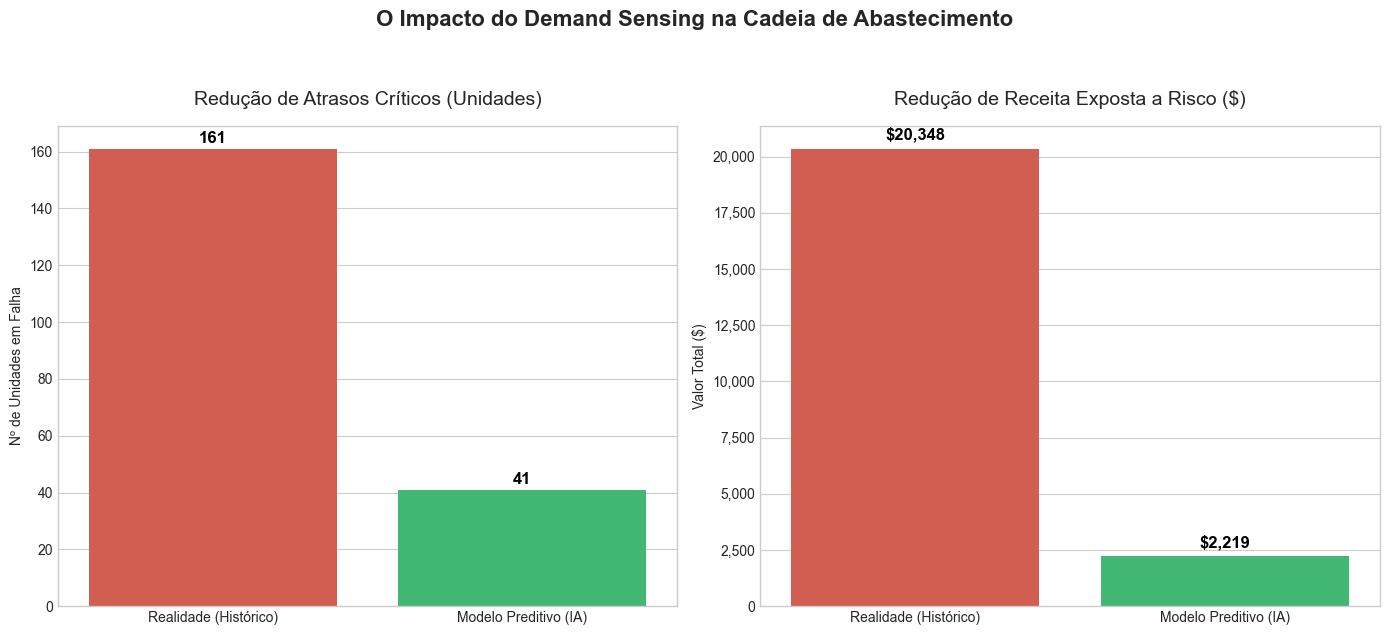

In [5]:
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Obter o Preço Unitário de cada produto a partir dos dados originais
df_precos = df_raw[['Product Name', 'Product Price']].drop_duplicates(subset=['Product Name'])

# 2. Cruzar a tabela de Auditoria com os Preços
df_financeiro = pd.merge(df_final, df_precos, left_on='Produto', right_on='Product Name', how='left')

# Filtrar apenas a semana de teste (26/Set a 02/Out)
semana_critica = df_financeiro[df_financeiro['Data'] >= '2017-09-26'].copy()

# 3. Calcular a Receita em Risco (Unidades Falhadas * Preço)
semana_critica['Risco_Real_Euros'] = semana_critica['Qtd_Falha_Real'] * semana_critica['Product Price']
semana_critica['Risco_IA_Euros'] = semana_critica['Qtd_Falha_IA'] * semana_critica['Product Price']

# Totais Financeiros
total_risco_real = semana_critica['Risco_Real_Euros'].sum()
total_risco_ia = semana_critica['Risco_IA_Euros'].sum()
receita_protegida = total_risco_real - total_risco_ia

print("--- RESUMO DE IMPACTO FINANCEIRO (1 Semana) ---")
print(f"Receita Exposta a Risco (Gestão Reativa): ${total_risco_real:,.2f}")
print(f"Receita Exposta a Risco (Gestão Predictiva): ${total_risco_ia:,.2f}")
print(f"✅ RECEITA PROTEGIDA (ROI do Modelo): ${receita_protegida:,.2f}")


plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

cores = ['#e74c3c', '#2ecc71'] # Vermelho para Real, Verde para IA
cenarios = ['Realidade (Histórico)', 'Modelo Preditivo (IA)']

# Gráfico 1: Unidades Falhadas
unidades = [total_falhas_real, total_falhas_ia]
sns.barplot(x=cenarios, y=unidades, ax=ax1, hue=cenarios, palette=cores, legend=False)
ax1.set_title('Redução de Atrasos Críticos (Unidades)', fontsize=14, pad=15)
ax1.set_ylabel('Nº de Unidades em Falha')
for i, v in enumerate(unidades):
    ax1.text(i, v + 2, f"{int(v)}", color='black', ha='center', fontweight='bold', fontsize=12)

# Gráfico 2: Receita em Risco
valores = [total_risco_real, total_risco_ia]
sns.barplot(x=cenarios, y=valores, ax=ax2, hue=cenarios, palette=cores, legend=False)
ax2.set_title('Redução de Receita Exposta a Risco ($)', fontsize=14, pad=15)
ax2.set_ylabel('Valor Total ($)')
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

for i, v in enumerate(valores):
    ax2.text(i, v + (max(valores)*0.02), f"${v:,.0f}", color='black', ha='center', fontweight='bold', fontsize=12)

plt.suptitle('O Impacto do Demand Sensing na Cadeia de Abastecimento', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

In [6]:
# Exportar a tabela final para a App
df_final.to_csv('..//app/dados_finais.csv', index=False)